In [5]:
import os
from utils import *

import pennylane as qml
from pennylane import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

SEED = 42

# Generating the dataset

We will generate a synthetic dataset, generated by solving the Lorentz system using the Euler method. The Lorenz equations are defined as:

$$
\dot{x} = \sigma (y-x)
$$
$$
\dot{y} = -y -zx + \rho x
$$
$$
\dot{z} = -\beta z +xy
$$

where $(x, y, z)$ are the variables and $(\sigma , \rho , \beta)$ are parameters. 

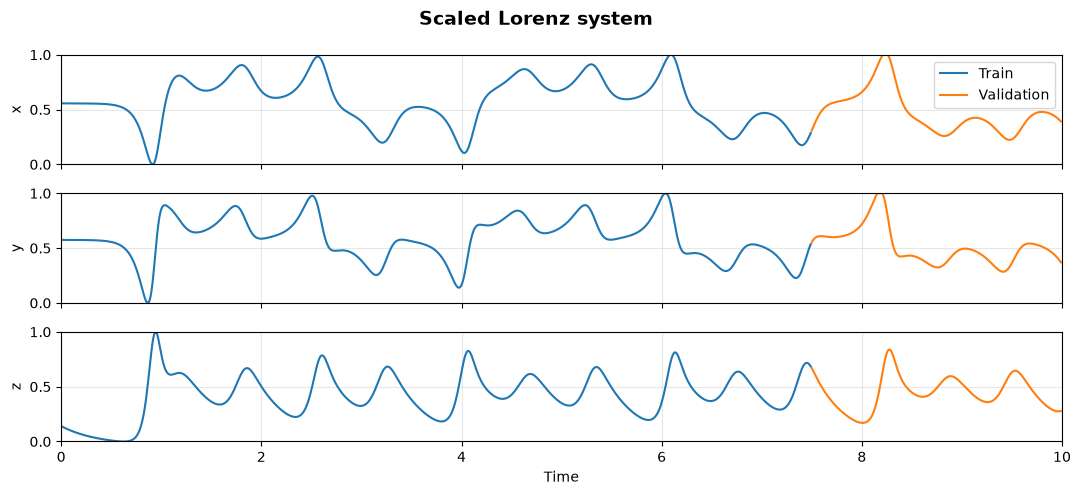

In [6]:
npoints = 1000
h = 0.01
params = [10, 28, 8 / 3]
init_point = [0, -0.01, 9]

dataset = generate_lorenz(
    npoints, 
    h,
    params, 
    init_point
)

# Trin test split
dataset_train, dataset_val = train_test_split(
    dataset,
    test_size=0.25,
    shuffle=False
)
time = np.arange(npoints) * h

time_tr = time[:len(dataset_train)]
time_val = time[len(dataset_train):]

# Scale the data to the range [0, 1]
scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(dataset_train)
val_scaled = scaler.transform(dataset_val)
val_scaled = np.clip(val_scaled, 0, 1)

plot_lorenz(train_scaled, val_scaled, time_tr, time_val)

# Classical 1D CNN

In this section, we use a classical approach for benchmarking purposes. The chosen architecture consists of:

- Conv1D(1 → 8, stride=1, kernel=3, padding)
- Conv1D(8 → 8, stride=1, kernel=3, padding)
- ReLU
- MaxPool1D(kernel=3)
- Flatten
- Linear(8 → 16)
- ReLU
- Linear(16 → 3)

In [11]:
# Params
batch_size = 128 
n_chanels = 3
window_size = 1
batch_size = 128
horizon = 1

# Training hyperparameters
epochs = 50
lr = 5e-4

In [12]:
# Create the sequences
x_tr, hor_tr = create_sequences(train_scaled, window_size, horizon)
x_val, hor_val = create_sequences(val_scaled, window_size, horizon)

x_tr = torch.from_numpy(x_tr).double()
hor_tr = torch.from_numpy(hor_tr).double()

x_val = torch.from_numpy(x_val).double()
hor_val = torch.from_numpy(hor_val).double()

tr_dataset = TensorDataset(x_tr, hor_tr)
tr_loader = DataLoader(tr_dataset, batch_size=batch_size, shuffle=False)

In [13]:
class Classic_CNN_Model(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv1d(
            in_channels=1,
            out_channels=8,
            kernel_size=3,
            stride=1,
            padding=1
        )
        self.conv2 = nn.Conv1d(
            in_channels=8,
            out_channels=8,
            kernel_size=3,
            stride=1,
            padding=1
        )
        self.maxpool1d = nn.MaxPool1d(kernel_size=3)
        self.linear1 = nn.Linear(8, 16)
        self.linear2 = nn.Linear(16, 3)

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = F.relu(x)
        x = self.maxpool1d(x)
        x = x.flatten(start_dim=1)
        x = self.linear1(x)
        x = F.relu(x)
        x = self.linear2(x)
        return x

In [14]:
reset_seeds(SEED)

# Create the model
model_classic_CNN = Classic_CNN_Model()
model_classic_CNN.double()

# Define optimizer and loss function
opt = torch.optim.Adam(params=model_classic_CNN.parameters(), lr=lr)
loss_fn = nn.MSELoss()

# Save the best model
best_state = None
best_val_loss = float("inf")

history = {"Loss": [], "Val loss": []}

print(30 * "#")
print("Starting training")
print(30 * "#")

for epoch in range(epochs):

    #Training
    model_classic_CNN.train()
    epoch_loss = 0
    for xb, yb in tr_loader:
        opt.zero_grad()
        pred = model_classic_CNN(xb)
        target = yb.reshape(yb.shape[0], -1)
        loss = loss_fn(pred, target)    
        loss.backward()
        opt.step()
        epoch_loss += loss.item()
    
    # Store average loss for this epoch
    epoch_loss /= len(tr_loader)
    history["Loss"].append(epoch_loss)

    # Evaluation
    model_classic_CNN.eval()
    with torch.no_grad():
        val_pred = model_classic_CNN(x_val)
        val_target = hor_val.reshape(hor_val.shape[0], -1)
        val_loss = loss_fn(val_pred, val_target).item()

    # Store val loss
    history["Val loss"].append(val_loss)

    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = {
            name: params.detach().clone()
            for name, params in model_classic_CNN.state_dict().items()
        }

    # Print training progress every 5 epochs
    if epoch == 0 or (epoch + 1) % 5 == 0:
        print(f"Epoch: {epoch + 1} | Loss: {epoch_loss:.4f} | Validation loss: {val_loss:.4f}")


if best_state is not None:
    model_classic_CNN.load_state_dict(best_state)

##############################
Starting training
##############################
Epoch: 1 | Loss: 0.3338 | Validation loss: 0.2719
Epoch: 5 | Loss: 0.2686 | Validation loss: 0.2148
Epoch: 10 | Loss: 0.2138 | Validation loss: 0.1678
Epoch: 15 | Loss: 0.1704 | Validation loss: 0.1303
Epoch: 20 | Loss: 0.1301 | Validation loss: 0.0954
Epoch: 25 | Loss: 0.0931 | Validation loss: 0.0649
Epoch: 30 | Loss: 0.0634 | Validation loss: 0.0425
Epoch: 35 | Loss: 0.0457 | Validation loss: 0.0311
Epoch: 40 | Loss: 0.0375 | Validation loss: 0.0270
Epoch: 45 | Loss: 0.0334 | Validation loss: 0.0253
Epoch: 50 | Loss: 0.0311 | Validation loss: 0.0245


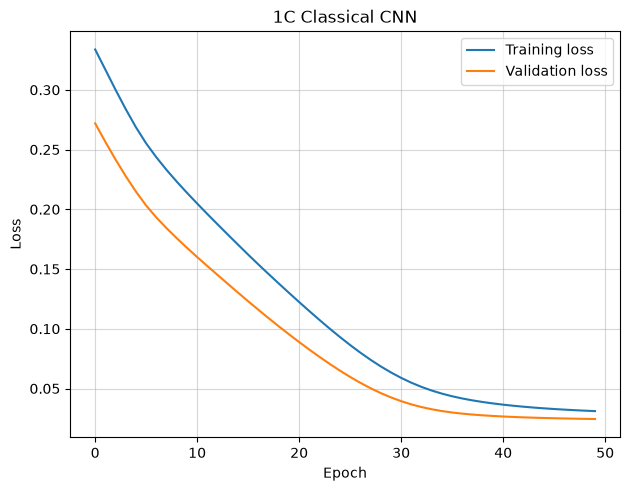

In [15]:
plot_loss(history, "1C Classical CNN")

In [16]:
# Evaluation mode
model_classic_CNN.eval()

with torch.no_grad():
    pred = model_classic_CNN(x_val)

pred_3d = pred.reshape(pred.shape[0], 1, 3)
target_3d = hor_val

# =====================
# RMSE
# =====================

squared_error = (pred_3d - target_3d) ** 2
mean_rmse_list = torch.sqrt(squared_error.mean(dim=(1, 2)))
mean_rmse = torch.sqrt(squared_error.mean())

# =====================
# MAE
# =====================

abs_error = torch.abs(pred_3d - target_3d)
mean_mae_list = abs_error.mean(dim=(1, 2))
mean_mae = abs_error.mean()

# =====================
# MAPE
# =====================

eps = 1e-8

percentage_error = torch.abs((target_3d - pred_3d) / (target_3d + eps))
mean_mape_list = percentage_error.mean(dim=(1, 2))
mean_mape = percentage_error.mean()

print(f"Global RMSE: {mean_rmse:.4f}")
print(f"Global MAE: {mean_mae:.4f}")
print(f"Global MAPE: {mean_mape:.4f}")

Global RMSE: 0.1564
Global MAE: 0.1295
Global MAPE: 0.3281


In [17]:
# Save the results to a CSV file
save_result_csv(
    "../results/lorenz_metrics.csv",
    {
        "forecasting": "short-term",
        "model": "1D Classical CNN",
        "MAPE": mean_mape,
        "MAE": mean_mae,
        "RMSE": mean_rmse,
    },
)

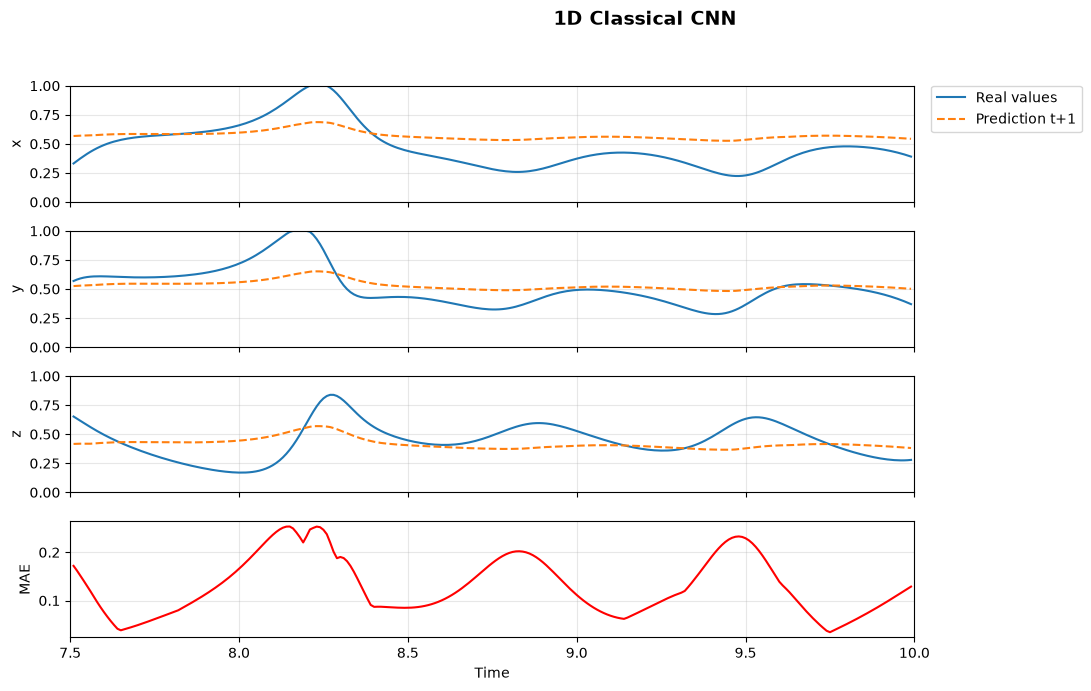

In [18]:
pred_x = pred_3d[:, :, 0]
pred_y = pred_3d[:, :, 1]
pred_z = pred_3d[:, :, 2]

plot_preds_and_error(
    pred_x,
    pred_y,
    pred_z,
    mean_mae_list,
    time_val,
    window_size,
    val_scaled,
    error="MAE",
    title="1D Classical CNN"
)